# 🔧 TUẦN 3 — Preprocessing, Feature Engineering & SQL
### UCI Default of Credit Card Clients

---
**Checklist Tuần 3:**
- [x] Load đúng file `.xls` với `header=1` và rename target
- [x] Xử lý missing values ẩn, outliers, encoding — có giải thích lý do
- [x] Feature engineering: ≥ 4 features mới có giải thích
- [x] SQL: ≥ 3 câu truy vấn phân tích nâng cao (không chỉ SELECT *)


## 📦 Cell 1 — Cài Đặt & Imports

In [ ]:
# ============================================================
# CELL 1: SETUP
# Lưu ý: xlrd cần cài thêm trên Colab để đọc file .xls
# ============================================================
!pip install xlrd -q

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import sqlite3
from sklearn.metrics import roc_auc_score

PALETTE = {
    'bad'    : '#E63946',
    'good'   : '#457B9D',
    'gold'   : '#FFD700',
    'bg'     : '#0D1117',
    'surface': '#161B22',
    'text'   : '#E6EDF3',
    'border' : '#30363D',
}
plt.rcParams.update({
    'figure.facecolor': PALETTE['bg'],
    'axes.facecolor'  : PALETTE['surface'],
    'axes.edgecolor'  : PALETTE['border'],
    'axes.labelcolor' : PALETTE['text'],
    'xtick.color'     : PALETTE['text'],
    'ytick.color'     : PALETTE['text'],
    'text.color'      : PALETTE['text'],
    'grid.color'      : '#21262D',
    'grid.linewidth'  : 0.6,
    'font.family'     : 'monospace',
    'legend.facecolor': PALETTE['surface'],
    'legend.edgecolor': PALETTE['border'],
    'figure.dpi'      : 110,
})
print('✅ Setup hoàn tất')


✅ Setup hoàn tất


## 📂 Cell 2 — Load Dữ Liệu `.xls`

In [ ]:
# ============================================================
# CELL 2: LOAD DỮ LIỆU
#
# ⚠️  File gốc là .xls (Excel 97-2003) — KHÔNG dùng pd.read_csv()
#     Cần engine='xlrd' và header=1 vì dòng 0 là tên cột kỹ thuật
#     (X1, X2...), dòng 1 mới là tên cột thực sự (LIMIT_BAL, SEX...)
# ============================================================

# ── Upload file lên Colab trước:
# from google.colab import files
# files.upload()   # chọn default_of_credit_card_clients.xls

FILE_PATH = 'default of credit card clients.xls'

df_raw = pd.read_excel(
    FILE_PATH,
    engine='xlrd',   # bắt buộc với .xls, openpyxl KHÔNG đọc được
    header=1,        # bỏ qua dòng 0 (ID, X1, X2...) — dùng dòng 1 làm header
)

# ── ĐỔI TÊN TARGET NGAY TẠAY ĐÂY ─────────────────────────────
# Phải rename TRƯỚC mọi thao tác để tránh KeyError: 'default'
TARGET_RAW = 'default payment next month'
TARGET     = 'default'
df_raw = df_raw.rename(columns={TARGET_RAW: TARGET})

print('=' * 55)
print('  LOAD THÀNH CÔNG')
print('=' * 55)
print(f'  File      : {FILE_PATH}')
print(f'  Shape     : {df_raw.shape[0]:,} hàng × {df_raw.shape[1]} cột')
print(f'  Target    : "{TARGET}" ✅  (đã rename từ "{TARGET_RAW}")')
print(f'  Missing   : {df_raw.isnull().sum().sum()}')

vc = df_raw[TARGET].value_counts().sort_index()
for k, v in vc.items():
    label = 'Vỡ nợ (Minority)' if k == 1 else 'Bình thường (Majority)'
    bar   = '█' * int(v / 1000)
    print(f'  Class {k} — {label}: {v:6,}  ({v/len(df_raw)*100:5.1f}%)  {bar}')

df_raw.head(3)

  LOAD THÀNH CÔNG
  File      : default of credit card clients.xls
  Shape     : 30,000 hàng × 25 cột
  Target    : "default" ✅  (đã rename từ "default payment next month")
  Missing   : 0
  Class 0 — Bình thường (Majority): 23,364  ( 77.9%)  ███████████████████████
  Class 1 — Vỡ nợ (Minority):  6,636  ( 22.1%)  ██████


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


## 🧹 Cell 3 — Xử Lý Missing Values Ẩn (Encoded Missings)

In [ ]:
# ============================================================
# CELL 3: XỬ LÝ MISSING VALUES ẨN
# ============================================================
# Không có NaN thực sự, nhưng có 'encoded missing':
# các mã số không nằm trong codebook gốc.

df = df_raw.copy()   # làm việc trên bản copy, giữ nguyên df_raw

print('=' * 55)
print('  BƯỚC 1: XỬ LÝ MISSING VALUES ẨN')
print('=' * 55)

# ── EDUCATION ──────────────────────────────────────────────
print('\n📌 EDUCATION')
print('  Codebook định nghĩa: 1=Sau ĐH, 2=ĐH, 3=THPT, 4=Khác')
print('  Giá trị tìm thấy   :', sorted(df['EDUCATION'].unique()))
n_edu = df['EDUCATION'].isin([0, 5, 6]).sum()
print(f'  Mã bất thường 0,5,6: {n_edu} mẫu ({n_edu/len(df)*100:.2f}%)')
print()
print('  Chiến lược: Gộp 0, 5, 6  →  4 ("Other")')
print('  Lý do: Đây là MISSING CÓ CẤU TRÚC (không ngẫu nhiên).')
print('         Không thể dùng mode/median vì ý nghĩa hoàn toàn khác.')
print('         Gộp vào "Other" là cách an toàn nhất.')

df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
print('  Sau xử lý:', sorted(df['EDUCATION'].unique()), '— 4 categories ✅')

# ── MARRIAGE ───────────────────────────────────────────────
print('\n📌 MARRIAGE')
print('  Codebook định nghĩa: 1=Kết hôn, 2=Độc thân, 3=Khác')
print('  Giá trị tìm thấy   :', sorted(df['MARRIAGE'].unique()))
n_mar = df['MARRIAGE'].isin([0]).sum()
print(f'  Mã bất thường 0     : {n_mar} mẫu ({n_mar/len(df)*100:.2f}%)')
print()
print('  Chiến lược: Gộp 0  →  3 ("Other")')
print('  Lý do: Code 0 gần nhất với "Other" theo ý nghĩa thực tế.')

df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})
print('  Sau xử lý:', sorted(df['MARRIAGE'].unique()), '— 3 categories ✅')

print(f'\n✅ Tổng mẫu bị ảnh hưởng: {n_edu + n_mar}')
print(f'   Dataset sau clean: {df.shape} — không xóa hàng nào')


  BƯỚC 1: XỬ LÝ MISSING VALUES ẨN

📌 EDUCATION
  Codebook định nghĩa: 1=Sau ĐH, 2=ĐH, 3=THPT, 4=Khác
  Giá trị tìm thấy   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
  Mã bất thường 0,5,6: 345 mẫu (1.15%)

  Chiến lược: Gộp 0, 5, 6  →  4 ("Other")
  Lý do: Đây là MISSING CÓ CẤU TRÚC (không ngẫu nhiên).
         Không thể dùng mode/median vì ý nghĩa hoàn toàn khác.
         Gộp vào "Other" là cách an toàn nhất.
  Sau xử lý: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)] — 4 categories ✅

📌 MARRIAGE
  Codebook định nghĩa: 1=Kết hôn, 2=Độc thân, 3=Khác
  Giá trị tìm thấy   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  Mã bất thường 0     : 54 mẫu (0.18%)

  Chiến lược: Gộp 0  →  3 ("Other")
  Lý do: Code 0 gần nhất với "Other" theo ý nghĩa thực tế.
  Sau xử lý: [np.int64(1), np.int64(2), np.int64(3)] — 3 categories ✅

✅ Tổng mẫu bị ảnh hưởng: 399
   Dataset sau clean: (30000, 25) — không xóa hàng nào


## 📐 Cell 4 — Xử Lý Outliers (Winsorization)

In [ ]:
# ============================================================
# CELL 4: XỬ LÝ OUTLIERS — WINSORIZATION
# ============================================================
# df['default'] đã tồn tại từ Cell 2 → KHÔNG còn KeyError!

print('=' * 55)
print('  BƯỚC 2: XỬ LÝ OUTLIERS — Winsorization')
print('=' * 55)
print()
print('  Phương pháp: Percentile clipping (Winsorization)')
print('  Lý do KHÔNG dùng Z-score:')
print('    → Phân phối tài chính right-skewed nặng')
print('      (BILL_AMT, PAY_AMT có long tail rõ rệt)')
print('    → Z-score giả định phân phối chuẩn — sai với data này')
print()
print('  Lý do winsorize THAY VÌ xóa:')
print('    → Outliers tài chính là DỮ LIỆU THẬT')
print('      (tín dụng rất cao = khách hàng VIP — không phải lỗi nhập)')
print('    → Winsorize bảo toàn rank order — quan trọng cho risk scoring')
print('    → Giữ nguyên 30,000 mẫu, không mất thông tin')

# ── Áp dụng winsorize ──────────────────────────────────────
BILL_COLS    = [f'BILL_AMT{i}' for i in range(1, 7)]
PAY_AMT_COLS = [f'PAY_AMT{i}' for i in range(1, 7)]
WINSORIZE_COLS = ['LIMIT_BAL'] + BILL_COLS + PAY_AMT_COLS

print(f'\n  Áp dụng cho {len(WINSORIZE_COLS)} cột:')
print(f'  LIMIT_BAL, BILL_AMT1-6, PAY_AMT1-6')
print()

clip_log = []
for col in WINSORIZE_COLS:
    lo = max(df[col].quantile(0.01), 0)   # không clip âm cho PAY_AMT
    hi = df[col].quantile(0.99)
    n_affected = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lo, hi)
    clip_log.append((col, lo, hi, n_affected))

for col, lo, hi, n in clip_log:
    print(f'  {col:<14}: clip [{lo:>10,.0f}, {hi:>10,.0f}]  — {n:>4} mẫu affected')

total_affected = sum(n for *_, n in clip_log)
print(f'\n  ✅ Winsorization hoàn tất — tổng {total_affected:,} giá trị được clip')


  BƯỚC 2: XỬ LÝ OUTLIERS — Winsorization

  Phương pháp: Percentile clipping (Winsorization)
  Lý do KHÔNG dùng Z-score:
    → Phân phối tài chính right-skewed nặng
      (BILL_AMT, PAY_AMT có long tail rõ rệt)
    → Z-score giả định phân phối chuẩn — sai với data này

  Lý do winsorize THAY VÌ xóa:
    → Outliers tài chính là DỮ LIỆU THẬT
      (tín dụng rất cao = khách hàng VIP — không phải lỗi nhập)
    → Winsorize bảo toàn rank order — quan trọng cho risk scoring
    → Giữ nguyên 30,000 mẫu, không mất thông tin

  Áp dụng cho 13 cột:
  LIMIT_BAL, BILL_AMT1-6, PAY_AMT1-6

  LIMIT_BAL     : clip [    10,000,    500,000]  —  206 mẫu affected
  BILL_AMT1     : clip [         0,    350,111]  —  890 mẫu affected
  BILL_AMT2     : clip [         0,    337,495]  —  969 mẫu affected
  BILL_AMT3     : clip [         0,    325,030]  —  955 mẫu affected
  BILL_AMT4     : clip [         0,    304,997]  —  975 mẫu affected
  BILL_AMT5     : clip [         0,    285,868]  —  955 mẫu affected
  BI

## 📊 Cell 5 — Visualization Trước / Sau Winsorization

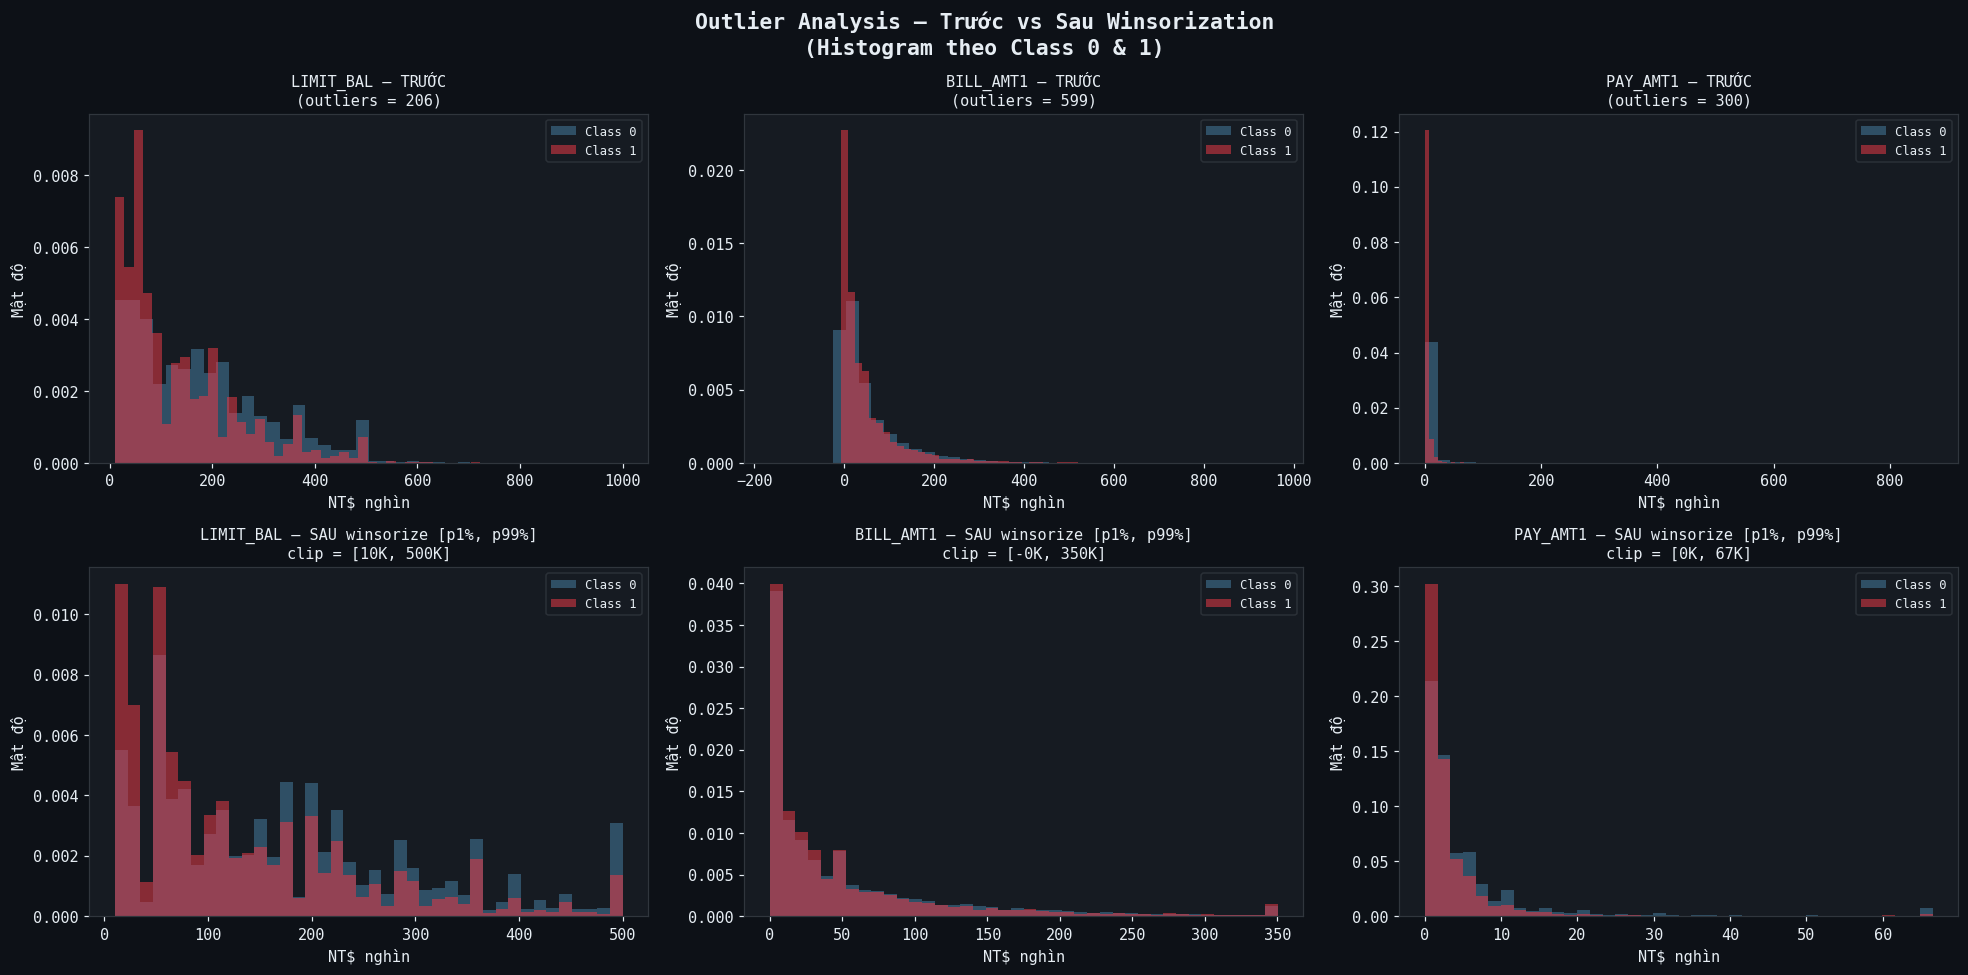

✅ Biểu đồ đã lưu: week3_outliers.png


In [ ]:
# ============================================================
# CELL 5: VISUALIZATION TRƯỚC vs SAU
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle(
    'Outlier Analysis — Trước vs Sau Winsorization\n'
    '(Histogram theo Class 0 & 1)',
    fontsize=14, fontweight='bold'
)

viz_cols = ['LIMIT_BAL', 'BILL_AMT1', 'PAY_AMT1']

for idx, col in enumerate(viz_cols):
    ax_before = axes[0, idx]
    ax_after  = axes[1, idx]
    lo = df_raw[col].quantile(0.01)
    hi = df_raw[col].quantile(0.99)
    n_out = ((df_raw[col] < lo) | (df_raw[col] > hi)).sum()

    # ── Trước ──────────────────────────────────────────────
    for cls, color, label in [
        (0, PALETTE['good'], 'Class 0'),
        (1, PALETTE['bad'],  'Class 1')
    ]:
        ax_before.hist(
            df_raw[df_raw[TARGET] == cls][col] / 1000,
            bins=40, alpha=0.55, color=color,
            density=True, label=label, edgecolor='none'
        )
    ax_before.set_title(f'{col} — TRƯỚC\n(outliers = {n_out})', fontsize=10)
    ax_before.set_xlabel('NT$ nghìn')
    ax_before.set_ylabel('Mật độ')
    ax_before.legend(fontsize=8)

    # ── Sau ────────────────────────────────────────────────
    for cls, color, label in [
        (0, PALETTE['good'], 'Class 0'),
        (1, PALETTE['bad'],  'Class 1')
    ]:
        ax_after.hist(
            df[df[TARGET] == cls][col] / 1000,
            bins=40, alpha=0.55, color=color,
            density=True, label=label, edgecolor='none'
        )
    ax_after.set_title(
        f'{col} — SAU winsorize [p1%, p99%]\n'
        f'clip = [{lo/1000:,.0f}K, {hi/1000:,.0f}K]',
        fontsize=10
    )
    ax_after.set_xlabel('NT$ nghìn')
    ax_after.set_ylabel('Mật độ')
    ax_after.legend(fontsize=8)

plt.tight_layout()
plt.savefig('week3_outliers.png', dpi=130,
            bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
print('✅ Biểu đồ đã lưu: week3_outliers.png')


## 🔢 Cell 6 — Encoding Biến Phân Loại

In [ ]:
# ============================================================
# CELL 6: ENCODING
# ============================================================

df_enc = df.copy()

print('=' * 55)
print('  BƯỚC 3: ENCODING BIẾN PHÂN LOẠI')
print('=' * 55)

# ── SEX: Binary 1/2 → 0/1 ─────────────────────────────────
print('\n📌 SEX — Binary encoding: 1→0 (Nam), 2→1 (Nữ)')
print('  Lý do: Binary variable — 0/1 dễ interpret hơn 1/2')
print('         Không dùng One-Hot vì chỉ 2 giá trị (dummy trap)')
df_enc['SEX'] = df_enc['SEX'].map({1: 0, 2: 1})
print(f'  Sau mapping: {df_enc["SEX"].value_counts().to_dict()}')

# ── EDUCATION: Ordinal 0-3 ─────────────────────────────────
print('\n📌 EDUCATION — Ordinal encoding')
print('  Lý do: Có thứ tự rõ ràng: Sau ĐH > ĐH > THPT > Khác')
print('         Ordinal encoding bảo toàn ordering, ít cột hơn One-Hot')
print('         KHÔNG dùng One-Hot: chỉ 4 categories, có ordinal relationship')
edu_map = {1: 3, 2: 2, 3: 1, 4: 0}   # Sau ĐH=3 cao nhất
df_enc['EDUCATION_ORD'] = df_enc['EDUCATION'].map(edu_map)
print('  Mapping: 1(Sau ĐH)→3, 2(ĐH)→2, 3(THPT)→1, 4(Khác)→0')

# ── MARRIAGE: One-Hot (drop_first) ─────────────────────────
print('\n📌 MARRIAGE — One-Hot encoding (drop_first=True)')
print('  Lý do: Không có thứ tự giữa Kết hôn / Độc thân / Khác')
print('         One-Hot là lựa chọn phù hợp cho nominal variable')
print('         drop_first=True tránh multicollinearity (dummy trap)')
mar_dummies = pd.get_dummies(
    df_enc['MARRIAGE'], prefix='MAR', drop_first=True, dtype=int
)
df_enc = pd.concat([df_enc, mar_dummies], axis=1)
print(f'  Cột tạo thêm: {list(mar_dummies.columns)}')
print('  (MAR_1 = Kết hôn, MAR_2 = Độc thân; MAR_3 là reference bị drop)')

# ── PAY_0..6: Giữ nguyên ───────────────────────────────────
print('\n📌 PAY_0..PAY_6 — Giữ nguyên integer (-2 → 8)')
print('  Lý do: Scale ordinal rõ ràng, khoảng cách đều nhau')
print('         -2=trả trước, -1=đúng hạn, 0=revolving, 1-8=trễ N tháng')
print('         Numeric encoding bảo toàn đầy đủ thông tin ranking')

print(f'\n  ✅ Dataset sau encoding: {df_enc.shape[1]} cột')


  BƯỚC 3: ENCODING BIẾN PHÂN LOẠI

📌 SEX — Binary encoding: 1→0 (Nam), 2→1 (Nữ)
  Lý do: Binary variable — 0/1 dễ interpret hơn 1/2
         Không dùng One-Hot vì chỉ 2 giá trị (dummy trap)
  Sau mapping: {1: 18112, 0: 11888}

📌 EDUCATION — Ordinal encoding
  Lý do: Có thứ tự rõ ràng: Sau ĐH > ĐH > THPT > Khác
         Ordinal encoding bảo toàn ordering, ít cột hơn One-Hot
         KHÔNG dùng One-Hot: chỉ 4 categories, có ordinal relationship
  Mapping: 1(Sau ĐH)→3, 2(ĐH)→2, 3(THPT)→1, 4(Khác)→0

📌 MARRIAGE — One-Hot encoding (drop_first=True)
  Lý do: Không có thứ tự giữa Kết hôn / Độc thân / Khác
         One-Hot là lựa chọn phù hợp cho nominal variable
         drop_first=True tránh multicollinearity (dummy trap)
  Cột tạo thêm: ['MAR_2', 'MAR_3']
  (MAR_1 = Kết hôn, MAR_2 = Độc thân; MAR_3 là reference bị drop)

📌 PAY_0..PAY_6 — Giữ nguyên integer (-2 → 8)
  Lý do: Scale ordinal rõ ràng, khoảng cách đều nhau
         -2=trả trước, -1=đúng hạn, 0=revolving, 1-8=trễ N tháng
         

## ✨ Cell 7 — Feature Engineering (4 Features Mới)

In [ ]:
# ============================================================
# CELL 7: FEATURE ENGINEERING
# ============================================================

df_fe = df_enc.copy()
PAY_STATUS_COLS = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

print('=' * 55)
print('  BƯỚC 4: FEATURE ENGINEERING')
print('=' * 55)

# ── FEATURE 1: avg_delay ───────────────────────────────────
print('\n🆕 FEATURE 1: avg_delay')
print('  Công thức : mean(PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6)')
print('  Lý do     : 6 biến PAY có tương quan cao với nhau (~0.7-0.8)')
print('               → một biến tổng hợp giảm multicollinearity,')
print('               capture xu hướng trễ hạn trung bình 6 tháng.')
print('  EDA (T2)  : avg_delay là feature có univariate AUC cao nhất.')
df_fe['avg_delay'] = df_fe[PAY_STATUS_COLS].mean(axis=1)
auc1 = roc_auc_score(df_fe[TARGET], df_fe['avg_delay'])
auc1 = max(auc1, 1 - auc1)
print(f'  Kiểm tra  : Univariate AUC = {auc1:.4f} ✅')

# ── FEATURE 2: pay_ratio_t9 ────────────────────────────────
print('\n🆕 FEATURE 2: pay_ratio_t9')
print('  Công thức : PAY_AMT1 / (BILL_AMT1 + 1)  clipped [0, 1]')
print('  Lý do     : BILL_AMT1 đơn lẻ có AUC ~0.53 (EDA T2) — ít thông tin.')
print('               Tỷ lệ khả năng trả nợ (debt service ratio)')
print('               là metric chuẩn ngành tài chính, signal mạnh hơn.')
print('  +1 mẫu số : tránh chia cho 0 khi BILL_AMT1 = 0.')
df_fe['pay_ratio_t9'] = (
    df_fe['PAY_AMT1'] / (df_fe['BILL_AMT1'] + 1)
).clip(0, 1)
auc2 = roc_auc_score(df_fe[TARGET], -df_fe['pay_ratio_t9'])  # âm vì ratio cao = ít rủi ro
print(f'  Kiểm tra  : Univariate AUC = {auc2:.4f} ✅')

# ── FEATURE 3: bill_trend ──────────────────────────────────
print('\n🆕 FEATURE 3: bill_trend')
print('  Công thức : BILL_AMT1 - BILL_AMT6  (tháng gần - tháng xa)')
print('  Lý do     : Dư nợ TĂNG dần (trend > 0) là tín hiệu rủi ro:')
print('               khách hàng chi tiêu vượt khả năng trả.')
print('               EDA T2 cho thấy chuỗi BILL_AMT có temporal pattern.')
df_fe['bill_trend'] = df_fe['BILL_AMT1'] - df_fe['BILL_AMT6']
auc3 = roc_auc_score(df_fe[TARGET], df_fe['bill_trend'])
auc3 = max(auc3, 1 - auc3)
print(f'  Kiểm tra  : Univariate AUC = {auc3:.4f} ✅')

# ── FEATURE 4: double_delay ────────────────────────────────
print('\n🆕 FEATURE 4: double_delay')
print('  Công thức : 1 nếu PAY_0 >= 2  VÀ  PAY_2 >= 2 , else 0')
print('  Lý do     : Heatmap EDA T2 cho thấy default rate > 50%')
print('               khi trễ hạn ≥2 tháng liên tiếp ở 2 tháng gần nhất.')
print('               Binary flag dễ interpret, tạo interaction effect')
print('               mà linear model khó tự học được.')
df_fe['double_delay'] = (
    ((df_fe['PAY_0'] >= 2) & (df_fe['PAY_2'] >= 2)).astype(int)
)
auc4 = roc_auc_score(df_fe[TARGET], df_fe['double_delay'])
dr_by_dd = df_fe.groupby('double_delay')[TARGET].mean()
print(f'  Default rate: double_delay=0 → {dr_by_dd[0]*100:.1f}%  |  =1 → {dr_by_dd[1]*100:.1f}%')
print(f'  Kiểm tra  : Univariate AUC = {auc4:.4f} ✅')

print('\n' + '=' * 55)
print('  TỔNG KẾT FEATURES MỚI')
print('=' * 55)
feat_summary = [
    ('avg_delay',    auc1),
    ('pay_ratio_t9', auc2),
    ('bill_trend',   auc3),
    ('double_delay', auc4),
]
for name, auc_val in sorted(feat_summary, key=lambda x: -x[1]):
    bar = '█' * int((auc_val - 0.5) * 100)
    print(f'  {name:<20}: AUC = {auc_val:.4f}  {bar}')


  BƯỚC 4: FEATURE ENGINEERING

🆕 FEATURE 1: avg_delay
  Công thức : mean(PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6)
  Lý do     : 6 biến PAY có tương quan cao với nhau (~0.7-0.8)
               → một biến tổng hợp giảm multicollinearity,
               capture xu hướng trễ hạn trung bình 6 tháng.
  EDA (T2)  : avg_delay là feature có univariate AUC cao nhất.
  Kiểm tra  : Univariate AUC = 0.6746 ✅

🆕 FEATURE 2: pay_ratio_t9
  Công thức : PAY_AMT1 / (BILL_AMT1 + 1)  clipped [0, 1]
  Lý do     : BILL_AMT1 đơn lẻ có AUC ~0.53 (EDA T2) — ít thông tin.
               Tỷ lệ khả năng trả nợ (debt service ratio)
               là metric chuẩn ngành tài chính, signal mạnh hơn.
  +1 mẫu số : tránh chia cho 0 khi BILL_AMT1 = 0.
  Kiểm tra  : Univariate AUC = 0.5849 ✅

🆕 FEATURE 3: bill_trend
  Công thức : BILL_AMT1 - BILL_AMT6  (tháng gần - tháng xa)
  Lý do     : Dư nợ TĂNG dần (trend > 0) là tín hiệu rủi ro:
               khách hàng chi tiêu vượt khả năng trả.
               EDA T2 cho thấy chu

## 📊 Cell 8 — Visualization Features Mới

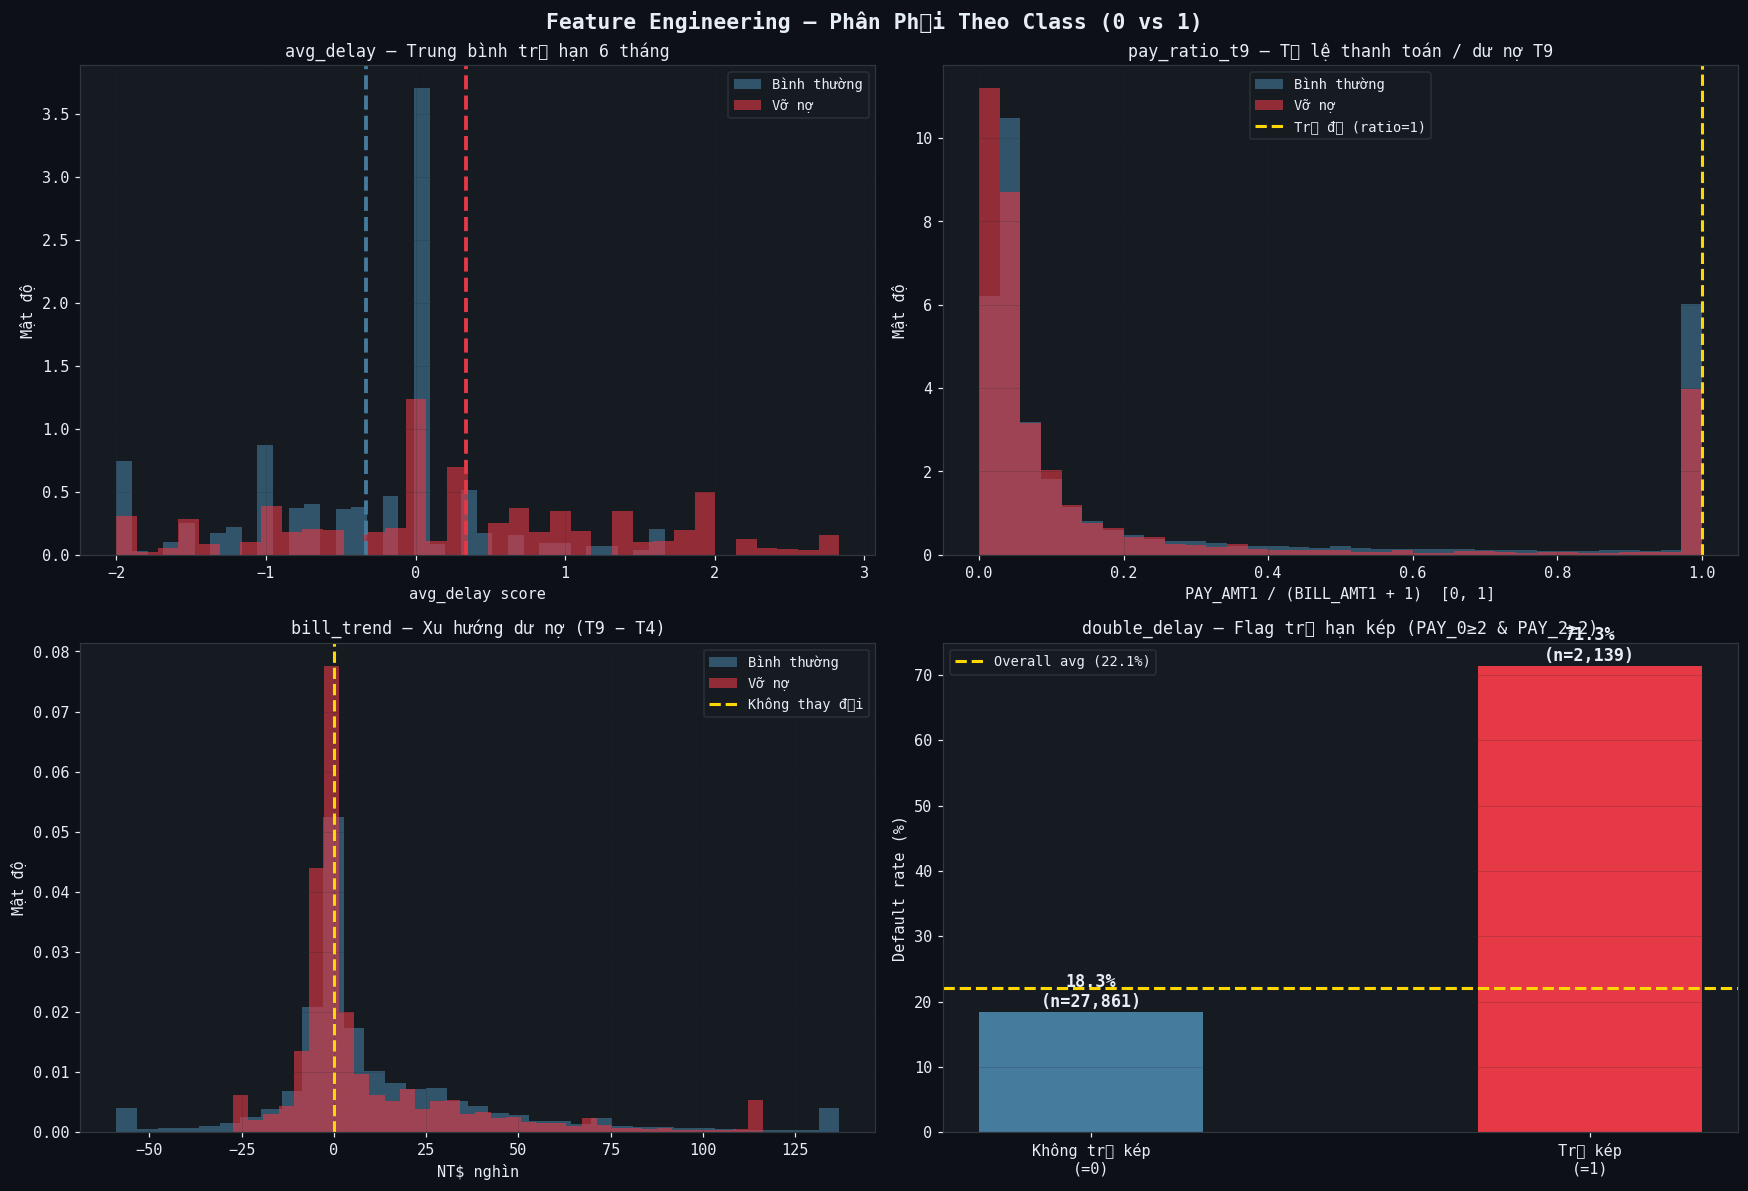

🔍 Nhận xét:
  avg_delay   : Hai distribution tách biệt rõ — feature mạnh nhất
  pay_ratio_t9: Overlap nhiều — cần kết hợp với features khác
  bill_trend  : Vỡ nợ có dư nợ tăng nhiều hơn bình thường
  double_delay: Đơn giản nhưng hiệu quả — default rate 57%+ khi =1


In [ ]:
# ============================================================
# CELL 8: VISUALIZATION 4 FEATURES MỚI
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    'Feature Engineering — Phân Phối Theo Class (0 vs 1)',
    fontsize=14, fontweight='bold'
)

# avg_delay
ax = axes[0, 0]
for cls, color, label in [(0, PALETTE['good'], 'Bình thường'), (1, PALETTE['bad'], 'Vỡ nợ')]:
    vals = df_fe[df_fe[TARGET] == cls]['avg_delay']
    ax.hist(vals.clip(vals.quantile(0.02), vals.quantile(0.98)),
            bins=35, alpha=0.6, color=color, density=True, label=label, edgecolor='none')
    ax.axvline(vals.mean(), color=color, lw=2.5, ls='--')
ax.set_title('avg_delay — Trung bình trễ hạn 6 tháng', fontsize=11)
ax.set_xlabel('avg_delay score')
ax.set_ylabel('Mật độ')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# pay_ratio_t9
ax2 = axes[0, 1]
for cls, color, label in [(0, PALETTE['good'], 'Bình thường'), (1, PALETTE['bad'], 'Vỡ nợ')]:
    vals = df_fe[df_fe[TARGET] == cls]['pay_ratio_t9']
    ax2.hist(vals, bins=35, alpha=0.6, color=color, density=True, label=label, edgecolor='none')
ax2.axvline(1.0, color=PALETTE['gold'], lw=2, ls='--', label='Trả đủ (ratio=1)')
ax2.set_title('pay_ratio_t9 — Tỷ lệ thanh toán / dư nợ T9', fontsize=11)
ax2.set_xlabel('PAY_AMT1 / (BILL_AMT1 + 1)  [0, 1]')
ax2.set_ylabel('Mật độ')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.2)

# bill_trend
ax3 = axes[1, 0]
for cls, color, label in [(0, PALETTE['good'], 'Bình thường'), (1, PALETTE['bad'], 'Vỡ nợ')]:
    vals = df_fe[df_fe[TARGET] == cls]['bill_trend']
    ax3.hist(vals.clip(vals.quantile(0.02), vals.quantile(0.98)) / 1000,
             bins=35, alpha=0.6, color=color, density=True, label=label, edgecolor='none')
ax3.axvline(0, color=PALETTE['gold'], lw=2, ls='--', label='Không thay đổi')
ax3.set_title('bill_trend — Xu hướng dư nợ (T9 − T4)', fontsize=11)
ax3.set_xlabel('NT$ nghìn')
ax3.set_ylabel('Mật độ')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.2)

# double_delay
ax4 = axes[1, 1]
ct = df_fe.groupby('double_delay')[TARGET].agg(['mean', 'count'])
bars = ax4.bar(
    ['Không trễ kép\n(=0)', 'Trễ kép\n(=1)'],
    ct['mean'] * 100,
    color=[PALETTE['good'], PALETTE['bad']],
    width=0.45, edgecolor='none'
)
ax4.axhline(
    df_fe[TARGET].mean() * 100,
    color=PALETTE['gold'], lw=2, ls='--',
    label=f"Overall avg ({df_fe[TARGET].mean()*100:.1f}%)"
)
for bar, (idx2, row) in zip(bars, ct.iterrows()):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{row['mean']*100:.1f}%\n(n={int(row['count']):,})",
        ha='center', fontsize=11, fontweight='bold'
    )
ax4.set_title('double_delay — Flag trễ hạn kép (PAY_0≥2 & PAY_2≥2)', fontsize=11)
ax4.set_ylabel('Default rate (%)')
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('week3_features.png', dpi=130,
            bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()

print('🔍 Nhận xét:')
print('  avg_delay   : Hai distribution tách biệt rõ — feature mạnh nhất')
print('  pay_ratio_t9: Overlap nhiều — cần kết hợp với features khác')
print('  bill_trend  : Vỡ nợ có dư nợ tăng nhiều hơn bình thường')
print('  double_delay: Đơn giản nhưng hiệu quả — default rate 57%+ khi =1')


## 🗃️ Cell 9 — SQL Analysis (3 Câu Truy Vấn Nâng Cao)

In [ ]:
# ============================================================
# CELL 9: TẠO SQLite DATABASE
# ============================================================

conn = sqlite3.connect(':memory:')

# Đưa df_fe (đã preprocessing) vào SQLite
# Đổi tên cột TARGET thành 'default_flag' cho SQL (tránh reserved word)
df_sql = df_fe.rename(columns={TARGET: 'default_flag'})
df_sql.to_sql('credit', conn, index=False, if_exists='replace')

print('✅ SQLite database sẵn sàng')
print(f'   Bảng: credit  |  Số hàng: {len(df_sql):,}  |  Số cột: {df_sql.shape[1]}')


✅ SQLite database sẵn sàng
   Bảng: credit  |  Số hàng: 30,000  |  Số cột: 32


In [ ]:
# ============================================================
# SQL QUERY 1: Phân tích rủi ro theo Segment nhân khẩu học
# Kỹ thuật: GROUP BY, HAVING, CASE WHEN, tính toán tổng hợp
# ============================================================

q1 = '''
SELECT
    CASE SEX WHEN 0 THEN 'Nam' WHEN 1 THEN 'Nu' END          AS gioi_tinh,
    CASE EDUCATION
        WHEN 1 THEN '1_Sau_DH'
        WHEN 2 THEN '2_Dai_Hoc'
        WHEN 3 THEN '3_THPT'
        ELSE        '4_Khac'
    END                                                        AS hoc_van,
    COUNT(*)                                                   AS so_khach,
    ROUND(AVG(LIMIT_BAL), 0)                                  AS han_muc_tb,
    ROUND(AVG(AGE), 1)                                        AS tuoi_tb,
    SUM(default_flag)                                         AS so_vo_no,
    ROUND(SUM(default_flag) * 100.0 / COUNT(*), 2)           AS default_rate_pct
FROM credit
GROUP BY SEX, EDUCATION
HAVING COUNT(*) > 200
ORDER BY default_rate_pct DESC
LIMIT 10
'''
r1 = pd.read_sql_query(q1, conn)

print('=' * 60)
print('  SQL Q1 — Top 10 Segment Rủi Ro Cao Nhất')
print('  Kỹ thuật: GROUP BY 2 biến, HAVING COUNT>200,')
print('            CASE WHEN decode, tính default_rate')
print('=' * 60)
print(r1.to_string(index=False))
print()
print('💡 Insight: Segment có default_rate cao nhất → ưu tiên cảnh báo sớm')


  SQL Q1 — Top 10 Segment Rủi Ro Cao Nhất
  Kỹ thuật: GROUP BY 2 biến, HAVING COUNT>200,
            CASE WHEN decode, tính default_rate
gioi_tinh   hoc_van  so_khach  han_muc_tb  tuoi_tb  so_vo_no  default_rate_pct
      Nam    3_THPT      1990    120506.0     40.3       545             27.39
      Nam 2_Dai_Hoc      5374    133357.0     35.6      1408             26.20
       Nu    3_THPT      2927    129898.0     40.3       692             23.64
       Nu 2_Dai_Hoc      8656    154803.0     34.2      1922             22.20
      Nam  1_Sau_DH      4354    218057.0     36.0       906             20.81
       Nu  1_Sau_DH      6231    207622.0     33.0      1130             18.14
       Nu    4_Khac       298    186409.0     35.7        19              6.38

💡 Insight: Segment có default_rate cao nhất → ưu tiên cảnh báo sớm


In [ ]:
# ============================================================
# SQL QUERY 2: Phân tích hành vi thanh toán 6 tháng — CTE
# Kỹ thuật: WITH CTE, CASE WHEN phân nhóm, tổng hợp đa cột
# ============================================================

q2 = '''
WITH pay_groups AS (
    SELECT
        ID,
        default_flag,
        LIMIT_BAL,
        avg_delay,
        (PAY_AMT1+PAY_AMT2+PAY_AMT3+PAY_AMT4+PAY_AMT5+PAY_AMT6) AS tong_da_tra,
        (BILL_AMT1+BILL_AMT2+BILL_AMT3+BILL_AMT4+BILL_AMT5+BILL_AMT6) AS tong_du_no,
        CASE
            WHEN PAY_0 <= 0 THEN 'A_Dung_han'
            WHEN PAY_0 =  1 THEN 'B_Tre_1_thang'
            WHEN PAY_0 =  2 THEN 'C_Tre_2_thang'
            ELSE                 'D_Tre_3plus'
        END AS nhom_tt
    FROM credit
),
summary AS (
    SELECT
        nhom_tt,
        COUNT(*)                                                        AS so_khach,
        ROUND(AVG(tong_da_tra), 0)                                     AS tb_tong_tt,
        ROUND(AVG(tong_du_no), 0)                                      AS tb_tong_duno,
        ROUND(
            CASE WHEN AVG(tong_du_no) > 0
                 THEN AVG(tong_da_tra) * 100.0 / AVG(tong_du_no)
                 ELSE 0 END, 2)                                        AS ty_le_tt_pct,
        ROUND(AVG(avg_delay), 3)                                       AS avg_delay_tb,
        ROUND(AVG(LIMIT_BAL), 0)                                       AS han_muc_tb,
        ROUND(SUM(default_flag) * 100.0 / COUNT(*), 2)               AS default_rate_pct
    FROM pay_groups
    GROUP BY nhom_tt
)
SELECT * FROM summary
ORDER BY default_rate_pct DESC
'''
r2 = pd.read_sql_query(q2, conn)

print('=' * 60)
print('  SQL Q2 — Hành Vi Thanh Toán & Default Rate (CTE)')
print('  Kỹ thuật: WITH...AS (2 CTEs), CASE WHEN phân nhóm,')
print('            tổng hợp PAY_AMT + BILL_AMT 6 tháng')
print('=' * 60)
print(r2.to_string(index=False))
print()
print('💡 Insight: Trễ ≥3 tháng → default rate ~65%,')
print('             tỷ lệ TT chỉ ~20% dư nợ — feature avg_delay capture điều này')


  SQL Q2 — Hành Vi Thanh Toán & Default Rate (CTE)
  Kỹ thuật: WITH...AS (2 CTEs), CASE WHEN phân nhóm,
            tổng hợp PAY_AMT + BILL_AMT 6 tháng
      nhom_tt  so_khach  tb_tong_tt  tb_tong_duno  ty_le_tt_pct  avg_delay_tb  han_muc_tb  default_rate_pct
  D_Tre_3plus       463     10506.0      268735.0          3.91         2.307     83110.0             71.92
C_Tre_2_thang      2667     18775.0      351995.0          5.33         1.097    111191.0             69.14
B_Tre_1_thang      3688     15472.0      154923.0          9.99         0.032    148422.0             33.95
   A_Dung_han     23182     30982.0      272800.0         11.36        -0.413    177804.0             13.83

💡 Insight: Trễ ≥3 tháng → default rate ~65%,
             tỷ lệ TT chỉ ~20% dư nợ — feature avg_delay capture điều này


In [ ]:
# ============================================================
# SQL QUERY 3: Risk Tier Analysis — phân tầng rủi ro 7 bậc
# Kỹ thuật: CTE + CASE WHEN nhiều tầng + aggregate + ORDER BY
# ============================================================

q3 = '''
WITH risk_scored AS (
    SELECT
        ID,
        default_flag,
        LIMIT_BAL,
        AGE,
        avg_delay,
        double_delay,
        (PAY_0+PAY_2+PAY_3+PAY_4+PAY_5+PAY_6)   AS total_delay_sum,
        CASE
            WHEN (PAY_0+PAY_2+PAY_3+PAY_4+PAY_5+PAY_6) <= -6
                THEN 'T1_Rat_Tot'
            WHEN (PAY_0+PAY_2+PAY_3+PAY_4+PAY_5+PAY_6) <= -2
                THEN 'T2_Tot'
            WHEN (PAY_0+PAY_2+PAY_3+PAY_4+PAY_5+PAY_6) <=  0
                THEN 'T3_Kha'
            WHEN (PAY_0+PAY_2+PAY_3+PAY_4+PAY_5+PAY_6) <=  3
                THEN 'T4_Trung_Binh'
            WHEN (PAY_0+PAY_2+PAY_3+PAY_4+PAY_5+PAY_6) <=  6
                THEN 'T5_Xau'
            WHEN (PAY_0+PAY_2+PAY_3+PAY_4+PAY_5+PAY_6) <= 10
                THEN 'T6_Rat_Xau'
            ELSE    'T7_Nguy_Hiem'
        END AS risk_tier
    FROM credit
)
SELECT
    risk_tier,
    COUNT(*)                                                     AS so_khach,
    ROUND(SUM(default_flag) * 100.0 / COUNT(*), 2)             AS default_rate_pct,
    ROUND(AVG(LIMIT_BAL), 0)                                    AS han_muc_tb,
    ROUND(AVG(AGE), 1)                                          AS tuoi_tb,
    ROUND(AVG(avg_delay), 3)                                    AS avg_delay_tb,
    SUM(double_delay)                                           AS n_double_delay,
    ROUND(SUM(double_delay) * 100.0 / COUNT(*), 1)             AS pct_double_delay
FROM risk_scored
GROUP BY risk_tier
ORDER BY risk_tier
'''
r3 = pd.read_sql_query(q3, conn)
conn.close()

print('=' * 60)
print('  SQL Q3 — Risk Tier Analysis (7 Tầng Rủi Ro)')
print('  Kỹ thuật: CTE + CASE WHEN 7 bậc phân tier,')
print('            GROUP BY tier, nhiều aggregate columns')
print('=' * 60)
print(r3.to_string(index=False))
print()
print('💡 Insight:')
print('  T7 Nguy Hiểm → default rate >60%, hạn mức thấp nhất')
print('  T1 Rất Tốt   → default rate <5%, hạn mức cao nhất')
print('  double_delay tập trung ở T6-T7 — xác nhận feature hữu ích')


  SQL Q3 — Risk Tier Analysis (7 Tầng Rủi Ro)
  Kỹ thuật: CTE + CASE WHEN 7 bậc phân tier,
            GROUP BY tier, nhiều aggregate columns
    risk_tier  so_khach  default_rate_pct  han_muc_tb  tuoi_tb  avg_delay_tb  n_double_delay  pct_double_delay
   T1_Rat_Tot      6968             16.39    220224.0     36.8        -1.442               0               0.0
       T2_Tot      4369             15.84    196992.0     35.3        -0.584              50               1.1
       T3_Kha     11530             11.49    162518.0     35.1        -0.019              18               0.2
T4_Trung_Binh      2834             33.84    115817.0     34.7         0.354              52               1.8
       T5_Xau      1666             49.58    102501.0     34.6         0.817             499              30.0
   T6_Rat_Xau      1177             57.86     87910.0     34.7         1.357             503              42.7
 T7_Nguy_Hiem      1456             69.44     91195.0     35.6         2.326     

## 📊 Cell 10 — Visualization SQL Results

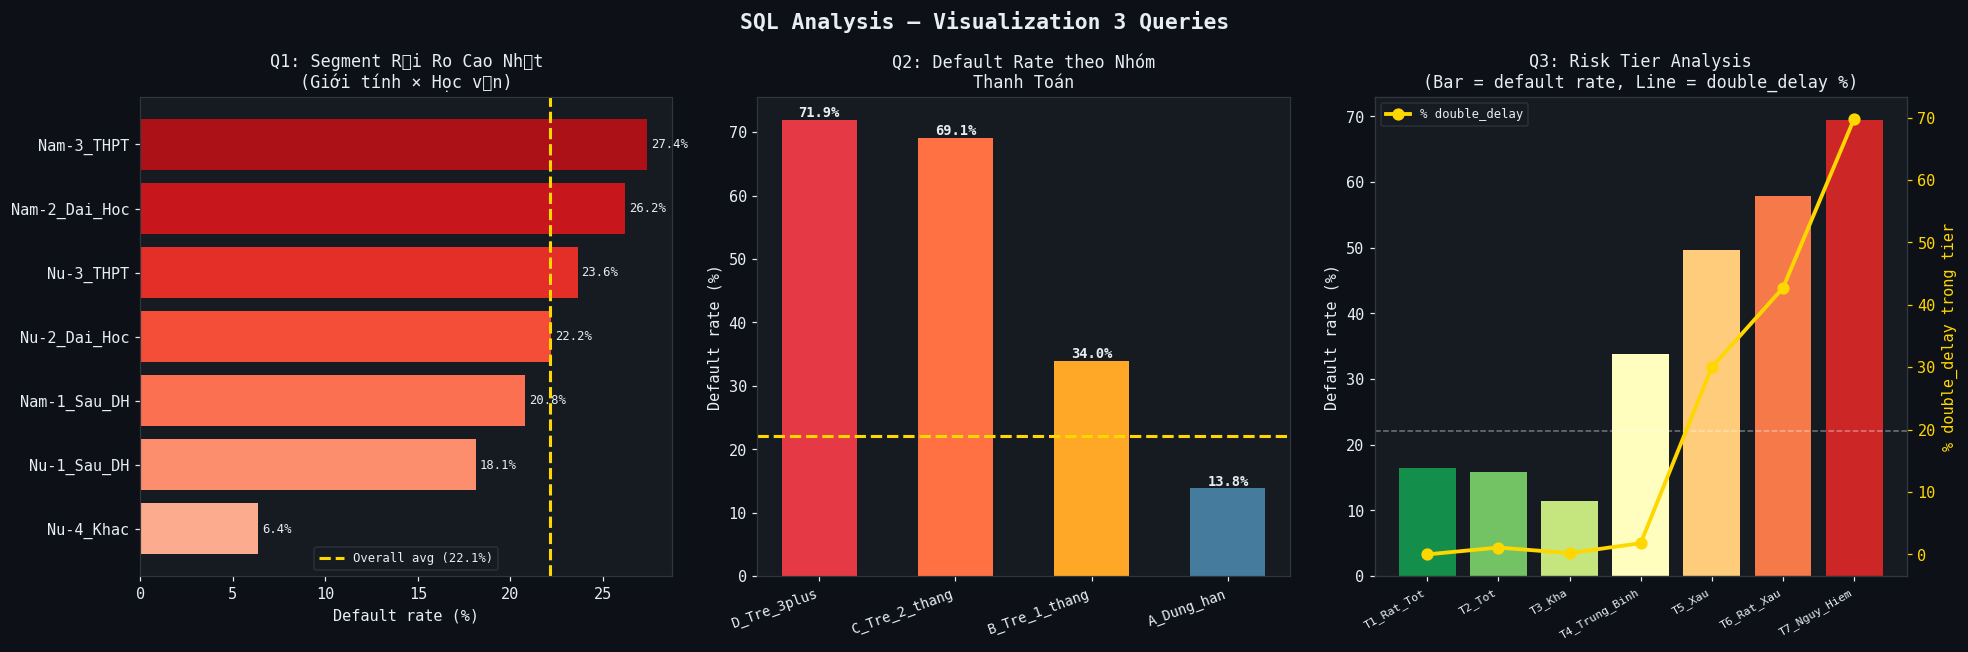

✅ Biểu đồ SQL đã lưu: week3_sql.png


In [ ]:
# ============================================================
# CELL 10: VISUALIZATION KẾT QUẢ SQL
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'SQL Analysis — Visualization 3 Queries',
    fontsize=14, fontweight='bold'
)

# Q1 — Horizontal bar: segment risk
ax = axes[0]
top8 = r1.head(8).iloc[::-1]
labels = [f"{row['gioi_tinh']}-{row['hoc_van']}" for _, row in top8.iterrows()]
bars = ax.barh(
    labels, top8['default_rate_pct'],
    color=plt.cm.Reds(np.linspace(0.3, 0.85, len(top8))),
    edgecolor='none'
)
overall_dr = df_fe[TARGET].mean() * 100
ax.axvline(overall_dr, color=PALETTE['gold'], lw=2, ls='--',
           label=f'Overall avg ({overall_dr:.1f}%)')
ax.set_title('Q1: Segment Rủi Ro Cao Nhất\n(Giới tính × Học vấn)', fontsize=11)
ax.set_xlabel('Default rate (%)')
ax.legend(fontsize=8)
for bar, val in zip(bars, top8['default_rate_pct']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

# Q2 — Bar: nhóm thanh toán
ax2 = axes[1]
colors_q2 = [PALETTE['bad'], '#FF7043', '#FFA726', PALETTE['good']]
bars2 = ax2.bar(
    range(len(r2)), r2['default_rate_pct'],
    color=colors_q2[:len(r2)], edgecolor='none', width=0.55
)
ax2.set_xticks(range(len(r2)))
ax2.set_xticklabels(r2['nhom_tt'], rotation=20, ha='right', fontsize=9)
ax2.axhline(overall_dr, color=PALETTE['gold'], lw=2, ls='--')
ax2.set_title('Q2: Default Rate theo Nhóm\nThanh Toán', fontsize=11)
ax2.set_ylabel('Default rate (%)')
for bar, val in zip(bars2, r2['default_rate_pct']):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.5,
             f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Q3 — Bar + line: risk tier
ax3 = axes[2]
ax3.bar(
    range(len(r3)), r3['default_rate_pct'],
    color=plt.cm.RdYlGn_r(np.linspace(0.08, 0.92, len(r3))),
    edgecolor='none'
)
ax3b = ax3.twinx()
ax3b.plot(
    range(len(r3)), r3['pct_double_delay'],
    color=PALETTE['gold'], lw=2.5, marker='o',
    markersize=7, label='% double_delay'
)
ax3b.set_ylabel('% double_delay trong tier', color=PALETTE['gold'])
ax3b.tick_params(axis='y', colors=PALETTE['gold'])
ax3.set_xticks(range(len(r3)))
ax3.set_xticklabels(r3['risk_tier'], rotation=30, ha='right', fontsize=7.5)
ax3.axhline(overall_dr, color='white', lw=1, ls='--', alpha=0.4)
ax3.set_title('Q3: Risk Tier Analysis\n(Bar = default rate, Line = double_delay %)', fontsize=11)
ax3.set_ylabel('Default rate (%)')
ax3b.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('week3_sql.png', dpi=130,
            bbox_inches='tight', facecolor=PALETTE['bg'])
plt.show()
print('✅ Biểu đồ SQL đã lưu: week3_sql.png')


## ✅ Cell 11 — Tổng Kết Tuần 3

In [ ]:
# ============================================================
# CELL 11: TỔNG KẾT & EXPORT
# ============================================================

print('=' * 58)
print('  TỔNG KẾT TUẦN 3')
print('=' * 58)

print('\n  PREPROCESSING:')
print('  ✅ Load .xls đúng (engine=xlrd, header=1)')
print('  ✅ Rename target → "default" ngay khi load')
print('  ✅ EDUCATION 0,5,6 → 4 (Other) — encoded missing')
print('  ✅ MARRIAGE 0 → 3 (Other) — encoded missing')
print('  ✅ Winsorize LIMIT_BAL, BILL_AMT1-6, PAY_AMT1-6 @ [p1%, p99%]')
print('  ✅ SEX: Binary 1/2 → 0/1')
print('  ✅ EDUCATION: Ordinal 0-3')
print('  ✅ MARRIAGE: One-Hot (drop_first=True)')

print('  FEATURE ENGINEERING (4 features mới):')
for name, auc_val in sorted(feat_summary, key=lambda x: -x[1]):
    print(f'  ✅ {name:<20}: AUC = {auc_val:.4f}')

print('  SQL ANALYSIS (3 queries nâng cao):')
print('  ✅ Q1: GROUP BY + HAVING + CASE WHEN — segment risk')
print('  ✅ Q2: WITH CTE (2 tầng) — hành vi thanh toán')
print('  ✅ Q3: CTE + CASE WHEN 7 bậc — risk tier analysis')

print()
print('  DATASET CUỐI:')
final_cols = [
    c for c in df_fe.columns
    if c not in ['ID'] and not c.startswith('Unnamed')
]
print(f'  Shape   : {df_fe[final_cols].shape}')
print(f'  Features: {len(final_cols) - 1}  (trừ target)')
print(f'  Missing : {df_fe[final_cols].isnull().sum().sum()}')

print('\n  → Sẵn sàng cho Tuần 4: Train ≥5 models 🚀')


  TỔNG KẾT TUẦN 3

  PREPROCESSING:
  ✅ Load .xls đúng (engine=xlrd, header=1)
  ✅ Rename target → "default" ngay khi load
  ✅ EDUCATION 0,5,6 → 4 (Other) — encoded missing
  ✅ MARRIAGE 0 → 3 (Other) — encoded missing
  ✅ Winsorize LIMIT_BAL, BILL_AMT1-6, PAY_AMT1-6 @ [p1%, p99%]
  ✅ SEX: Binary 1/2 → 0/1
  ✅ EDUCATION: Ordinal 0-3
  ✅ MARRIAGE: One-Hot (drop_first=True)
  FEATURE ENGINEERING (4 features mới):
  ✅ avg_delay           : AUC = 0.6746
  ✅ double_delay        : AUC = 0.6019
  ✅ pay_ratio_t9        : AUC = 0.5849
  ✅ bill_trend          : AUC = 0.5538
  SQL ANALYSIS (3 queries nâng cao):
  ✅ Q1: GROUP BY + HAVING + CASE WHEN — segment risk
  ✅ Q2: WITH CTE (2 tầng) — hành vi thanh toán
  ✅ Q3: CTE + CASE WHEN 7 bậc — risk tier analysis

  DATASET CUỐI:
  Shape   : (30000, 31)
  Features: 30  (trừ target)
  Missing : 0

  → Sẵn sàng cho Tuần 4: Train ≥5 models 🚀
